# SOB4ES - Comparador del barrido de random_state (Prueba 3)

Este notebook consolida los resultados generados por el barrido de `random_state` (0-100) en los 8 notebooks de modelos de SOB4ES (`xgboost-model`, `xgb_multisalida`, `rf-model`, `rf_multisalida`, `regressorchain`, `reg-model`, `mlp_multisalida`, `mlp_custom_loss`).

**Objetivo:** determinar qué modelo o modelos son consistentemente los más prominentes en el ranking a lo largo de 101 semillas distintas, en lugar de fiarse de una única ejecución con `random_state=42` (ver Prueba 2, que ya demostró que el ranking con una sola semilla no es estable).

Requisito previo: haber ejecutado la celda de barrido en cada uno de los 8 notebooks de modelos, lo que genera un `*_barrido_rs.csv` por modelo bajo `output/models/barrido_rs_<modelo>/`.

Este notebook tiene dos bloques independientes:
- **Bloque A — Ranking global:** compara los modelos usando la media de R² de los 2 targets prioritarios (`earthworm_shannon_z`, `earthworm_richness_z`). Da una conclusión rápida de "qué modelo es el más prominente en general".
- **Bloque B — Ranking por target:** compara los modelos target a target sobre los 21 targets del proyecto, para detectar si un mismo modelo domina en todos o si conviene uno distinto según el target.


## 0. Configuración

In [1]:
import os
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paleta de colores unificada (identica a la usada en comparador_modelos.ipynb)
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}

# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

os.makedirs('output/regresion', exist_ok=True)
os.makedirs('output/regresion/graphs', exist_ok=True)

---
# Bloque A — Ranking global (targets prioritarios)

Usa la media de R² de `earthworm_shannon_z` y `earthworm_richness_z` como criterio único de ranking por semilla.

## A.1 Carga y unificación de los CSVs del barrido

Se cargan los 8 `*_barrido_rs.csv`. Si alguno no existe todavía (falta ejecutar ese barrido en su notebook), se avisa y se continúa con los que sí están disponibles.

In [2]:
BARRIDO_PATHS = {
    'XGBoost Individual':               'output/models/xgb/barrido_rs_xgb/xgb_barrido_rs.csv',
    'XGBoost Multisalida':              'output/models/xgb_multi/barrido_rs_xgb_multi/xgb_multi_barrido_rs.csv',
    'RF Individual':                    'output/models/rf/barrido_rs_rf/rf_barrido_rs.csv',
    'RandomForest Multisalida':         'output/models/rf_multi/barrido_rs_rf_multi/rf_multi_barrido_rs.csv',
    'Random Forest con RegressorChain': 'output/models/chain/barrido_rs_chain/chain_barrido_rs.csv',
    'Regresión Individual':             'output/models/reg/barrido_rs_ridge/ridge_barrido_rs.csv',
    'MLP Estandar':                     'output/models/mlp/barrido_rs_mlp/mlp_barrido_rs.csv',
    'MLP Perdida Custom':               'output/models/mlp_custom/barrido_rs_mlp_custom/mlp_custom_barrido_rs.csv',
}

COLS_COMUNES = ['random_state', 'earthworm_shannon_z_r2', 'earthworm_richness_z_r2']

dfs_barrido = []
print('Cargando resultados del barrido de random_state por modelo...\n')
for nombre_modelo, ruta in BARRIDO_PATHS.items():
    if not os.path.exists(ruta):
        print(f'  [AVISO] No encontrado: {ruta} (¿falta ejecutar ese barrido?)')
        continue
    df_m = pd.read_csv(ruta)[COLS_COMUNES].copy()
    df_m['Modelo'] = nombre_modelo
    df_m['r2_medio_prioritarios'] = df_m[['earthworm_shannon_z_r2', 'earthworm_richness_z_r2']].mean(axis=1)
    dfs_barrido.append(df_m)
    print(f'  {nombre_modelo:<35} -> {len(df_m)} semillas cargadas')

df_barrido_todos = pd.concat(dfs_barrido, ignore_index=True)
print(f'\nTotal de filas combinadas: {len(df_barrido_todos)} '
      f'({df_barrido_todos["Modelo"].nunique()} modelos x {df_barrido_todos["random_state"].nunique()} semillas)')


Cargando resultados del barrido de random_state por modelo...

  XGBoost Individual                  -> 90 semillas cargadas
  XGBoost Multisalida                 -> 90 semillas cargadas
  RF Individual                       -> 90 semillas cargadas
  RandomForest Multisalida            -> 90 semillas cargadas
  Random Forest con RegressorChain    -> 491 semillas cargadas
  Regresión Individual                -> 90 semillas cargadas
  MLP Estandar                        -> 90 semillas cargadas
  MLP Perdida Custom                  -> 90 semillas cargadas

Total de filas combinadas: 1121 (8 modelos x 491 semillas)


## A.2 Ranking por semilla

Para cada `random_state`, se ordenan los 8 modelos de mayor a menor R² medio y se guarda la posición de cada uno (1º a 8º).

Se usa `sort_values` + `cumcount` en vez de `groupby().apply()` para evitar que versiones recientes de pandas (2.2+) excluyan la columna de agrupación del resultado.

In [3]:
df_rankings = (
    df_barrido_todos
    .sort_values(['random_state', 'r2_medio_prioritarios'], ascending=[True, False])
    .reset_index(drop=True)
)
df_rankings['posicion'] = df_rankings.groupby('random_state').cumcount() + 1

print('Ejemplo de ranking para random_state=42:')
print(df_rankings[df_rankings['random_state'] == 42]
      [['posicion', 'Modelo', 'earthworm_shannon_z_r2', 'earthworm_richness_z_r2']]
      .to_string(index=False))


Ejemplo de ranking para random_state=42:
Empty DataFrame
Columns: [posicion, Modelo, earthworm_shannon_z_r2, earthworm_richness_z_r2]
Index: []


## A.3 Agregación final: estabilidad y frecuencia en el ranking

Esta es la tabla clave de la Prueba 3: para cada modelo, calcula el R² medio/std a lo largo de las 101 semillas y cuántas veces queda en el top-1 / top-3 del ranking.

In [4]:
resumen_barrido = df_barrido_todos.groupby('Modelo').agg(
    r2_medio      = ('r2_medio_prioritarios', 'mean'),
    r2_std        = ('r2_medio_prioritarios', 'std'),
    r2_min        = ('r2_medio_prioritarios', 'min'),
    r2_max        = ('r2_medio_prioritarios', 'max'),
).reset_index()

n_semillas = df_barrido_todos['random_state'].nunique()

for k in [1, 2, 3, 5]:
    frecuencia_k = (df_rankings[df_rankings['posicion'] <= k]['Modelo']
                    .value_counts().reindex(resumen_barrido['Modelo']).fillna(0).astype(int))
    resumen_barrido[f'veces_top{k}'] = resumen_barrido['Modelo'].map(frecuencia_k)
    resumen_barrido[f'pct_top{k}']   = (resumen_barrido[f'veces_top{k}'] / n_semillas * 100).round(1)

resumen_barrido = resumen_barrido.sort_values('veces_top1', ascending=False).reset_index(drop=True)
resumen_barrido.index += 1

print('Resumen del barrido de random_state (0-100) por modelo:')
print('=' * 120)
print(resumen_barrido.round(4).to_string())
print('=' * 120)
print(f"\nModelo mas prominente (mas veces en el top-1): {resumen_barrido.iloc[0]['Modelo']} "
      f"({resumen_barrido.iloc[0]['veces_top1']}/{n_semillas} semillas)")

Resumen del barrido de random_state (0-100) por modelo:
                             Modelo  r2_medio  r2_std  r2_min  r2_max  veces_top1  pct_top1  veces_top2  pct_top2  veces_top3  pct_top3  veces_top5  pct_top5
1  Random Forest con RegressorChain    0.5035  0.0115  0.4727  0.5368         401      81.7         401      81.7         488      99.4         491     100.0
2               XGBoost Multisalida    0.5595  0.0088  0.5345  0.5851          89      18.1          90      18.3          90      18.3          90      18.3
3                     RF Individual    0.5253  0.0081  0.5077  0.5436           1       0.2          90      18.3          90      18.3          90      18.3
4                MLP Perdida Custom    0.3893  0.0585  0.2348  0.5041           0       0.0           0       0.0           1       0.2          16       3.3
5                      MLP Estandar    0.4274  0.0387  0.2923  0.5147           0       0.0           0       0.0           2       0.4          40       

## A.4 Gráficos: dispersión de R² y frecuencia en el top-1

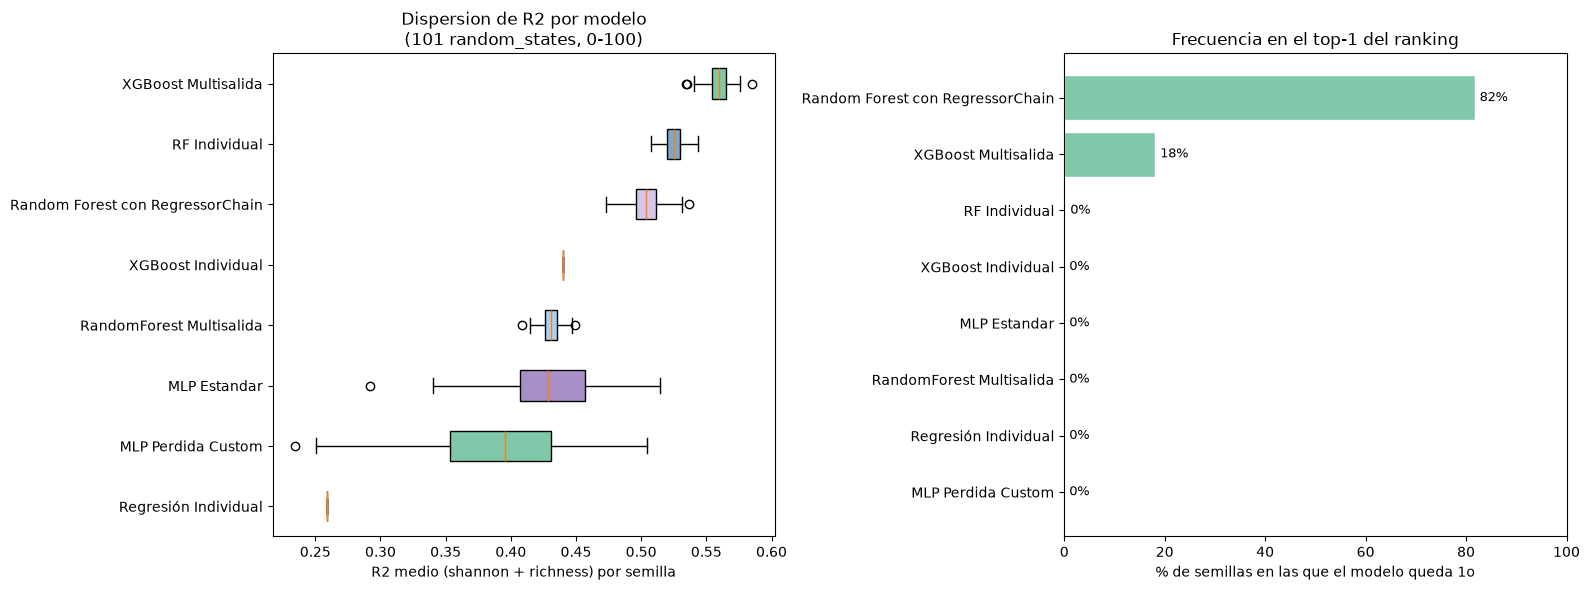

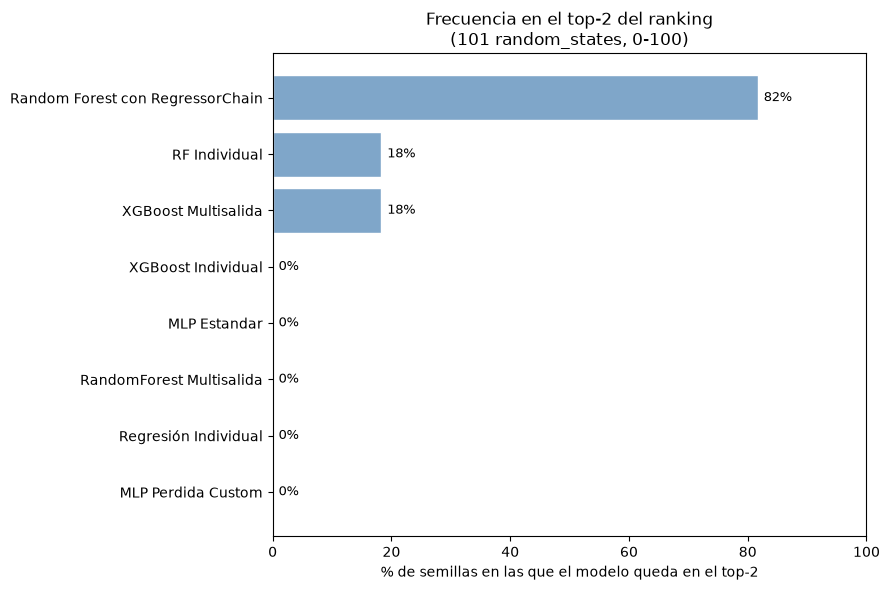

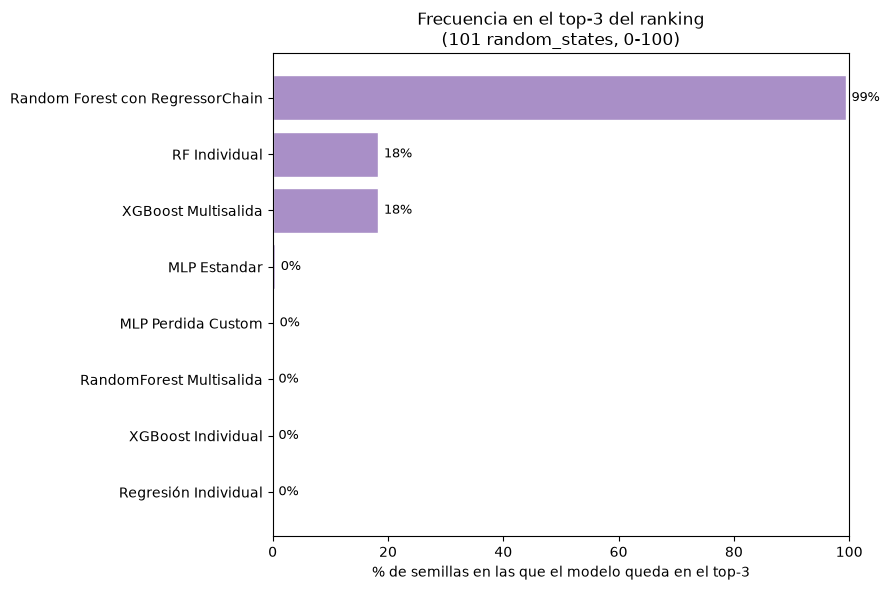

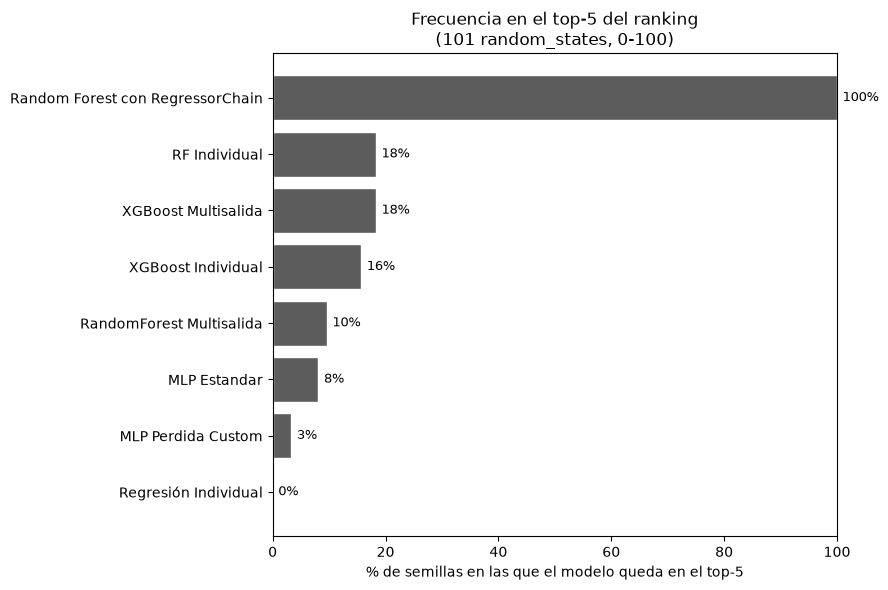

In [5]:
orden_modelos_barrido = resumen_barrido.sort_values('r2_medio')['Modelo']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot de R2 medio (shannon+richness) por modelo a lo largo de las 101 semillas
data_box = [df_barrido_todos[df_barrido_todos['Modelo'] == m]['r2_medio_prioritarios'].values
            for m in orden_modelos_barrido]
bp = axes[0].boxplot(data_box, orientation='horizontal', patch_artist=True, tick_labels=orden_modelos_barrido)
for patch, color in zip(bp['boxes'], palette_cycle(len(orden_modelos_barrido))):
    patch.set_facecolor(color)
axes[0].set_xlabel('R2 medio (shannon + richness) por semilla')
axes[0].set_title('Dispersion de R2 por modelo\n(101 random_states, 0-100)', fontsize=12)

# Barras de frecuencia en el top-1
_orden_top1 = resumen_barrido.sort_values('veces_top1')
axes[1].barh(_orden_top1['Modelo'], _orden_top1['pct_top1'], color=PALETTE['green'], edgecolor='white')
for i, v in enumerate(_orden_top1['pct_top1']):
    axes[1].text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9)
axes[1].set_xlabel('% de semillas en las que el modelo queda 1o')
axes[1].set_title('Frecuencia en el top-1 del ranking', fontsize=12)
axes[1].set_xlim(0, 100)

plt.tight_layout()
fig.savefig('output/regresion/graphs/barrido_rs_resumen.png', dpi=250, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# Grafico: frecuencia en el top-2
# ------------------------------------------------------------
_orden_top2 = resumen_barrido.sort_values('veces_top2')

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(_orden_top2['Modelo'], _orden_top2['pct_top2'], color=PALETTE['blue'], edgecolor='white')
for i, v in enumerate(_orden_top2['pct_top2']):
    ax.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9)
ax.set_xlabel('% de semillas en las que el modelo queda en el top-2')
ax.set_title('Frecuencia en el top-2 del ranking\n(101 random_states, 0-100)', fontsize=12)
ax.set_xlim(0, 100)

plt.tight_layout()
fig.savefig('output/regresion/graphs/barrido_rs_top2.png', dpi=250, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# Grafico: frecuencia en el top-3
# ------------------------------------------------------------
_orden_top3 = resumen_barrido.sort_values('veces_top3')

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(_orden_top3['Modelo'], _orden_top3['pct_top3'], color=PALETTE['purple'], edgecolor='white')
for i, v in enumerate(_orden_top3['pct_top3']):
    ax.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9)
ax.set_xlabel('% de semillas en las que el modelo queda en el top-3')
ax.set_title('Frecuencia en el top-3 del ranking\n(101 random_states, 0-100)', fontsize=12)
ax.set_xlim(0, 100)

plt.tight_layout()
fig.savefig('output/regresion/graphs/barrido_rs_top3.png', dpi=250, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# Grafico: frecuencia en el top-5
# ------------------------------------------------------------
_orden_top5 = resumen_barrido.sort_values('veces_top5')

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(_orden_top5['Modelo'], _orden_top5['pct_top5'], color=PALETTE['gray_dark'], edgecolor='white')
for i, v in enumerate(_orden_top5['pct_top5']):
    ax.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9)
ax.set_xlabel('% de semillas en las que el modelo queda en el top-5')
ax.set_title('Frecuencia en el top-5 del ranking\n(101 random_states, 0-100)', fontsize=12)
ax.set_xlim(0, 100)

plt.tight_layout()
fig.savefig('output/regresion/graphs/barrido_rs_top5.png', dpi=250, bbox_inches='tight')
plt.show()


## A.5 Exportación de resultados (ranking global)

In [6]:
df_barrido_todos.to_csv('output/regresion/barrido_rs_todos_los_modelos.csv', index=False)
df_rankings.to_csv('output/regresion/barrido_rs_rankings_por_semilla.csv', index=False)
resumen_barrido.to_csv('output/regresion/barrido_rs_resumen.csv', index=False)

print('Guardado:')
print('  output/regresion/barrido_rs_todos_los_modelos.csv    (una fila por modelo x semilla)')
print('  output/regresion/barrido_rs_rankings_por_semilla.csv (posicion de cada modelo en cada semilla)')
print('  output/regresion/barrido_rs_resumen.csv              (tabla resumen para el informe de la Prueba 3)')


Guardado:
  output/regresion/barrido_rs_todos_los_modelos.csv    (una fila por modelo x semilla)
  output/regresion/barrido_rs_rankings_por_semilla.csv (posicion de cada modelo en cada semilla)
  output/regresion/barrido_rs_resumen.csv              (tabla resumen para el informe de la Prueba 3)


---
# Bloque B — Ranking por target (los 21 targets)

El bloque A resume el rendimiento en 2 targets prioritarios. Este bloque desglosa el mismo análisis en los 21 targets del proyecto, para ver si el modelo más prominente cambia según el target.

## B.1 Carga en formato largo (modelo x semilla x target)

Reutiliza `BARRIDO_PATHS` del bloque A. Convierte cada CSV a formato largo (`melt`) para tener una fila por combinación de modelo, semilla y target.

In [7]:
filas_largas = []
print('Cargando resultados del barrido de random_state por modelo (todos los targets)...\n')
for nombre_modelo, ruta in BARRIDO_PATHS.items():
    if not os.path.exists(ruta):
        print(f'  [AVISO] No encontrado: {ruta} (¿falta ejecutar ese barrido?)')
        continue
    df_m = pd.read_csv(ruta)

    # columnas de R2 por target: '<target>_r2'
    cols_r2 = [c for c in df_m.columns if c.endswith('_r2') and c not in ('r2_global',)]

    df_largo = df_m[['random_state'] + cols_r2].melt(
        id_vars='random_state', var_name='target', value_name='r2'
    )
    df_largo['target'] = df_largo['target'].str.removesuffix('_r2')
    df_largo['Modelo'] = nombre_modelo
    filas_largas.append(df_largo)
    print(f'  {nombre_modelo:<35} -> {df_m["random_state"].nunique()} semillas x {len(cols_r2)} targets')

df_barrido_por_target = pd.concat(filas_largas, ignore_index=True)
print(f'\nTotal de filas combinadas: {len(df_barrido_por_target)} '
      f'({df_barrido_por_target["Modelo"].nunique()} modelos x '
      f'{df_barrido_por_target["random_state"].nunique()} semillas x '
      f'{df_barrido_por_target["target"].nunique()} targets)')


Cargando resultados del barrido de random_state por modelo (todos los targets)...

  XGBoost Individual                  -> 90 semillas x 21 targets
  XGBoost Multisalida                 -> 90 semillas x 21 targets
  RF Individual                       -> 90 semillas x 21 targets
  RandomForest Multisalida            -> 90 semillas x 21 targets
  Random Forest con RegressorChain    -> 491 semillas x 21 targets
  Regresión Individual                -> 90 semillas x 21 targets
  MLP Estandar                        -> 90 semillas x 21 targets
  MLP Perdida Custom                  -> 90 semillas x 21 targets

Total de filas combinadas: 23541 (8 modelos x 491 semillas x 21 targets)


## B.2 Ranking por semilla y por target

Igual que en el bloque A, pero ahora la agrupación es `(random_state, target)`: cada target tiene su propio ranking de 8 modelos por semilla.

In [8]:
df_rankings_target = (
    df_barrido_por_target
    .sort_values(['random_state', 'target', 'r2'], ascending=[True, True, False])
    .reset_index(drop=True)
)
df_rankings_target['posicion'] = df_rankings_target.groupby(['random_state', 'target']).cumcount() + 1

print('Ejemplo de ranking para random_state=42, target earthworm_shannon_z:')
print(df_rankings_target[(df_rankings_target['random_state'] == 42) & (df_rankings_target['target'] == 'earthworm_shannon_z')]
      [['posicion', 'Modelo', 'r2']]
      .to_string(index=False))


Ejemplo de ranking para random_state=42, target earthworm_shannon_z:
Empty DataFrame
Columns: [posicion, Modelo, r2]
Index: []


## B.3 Agregación final por target

Para cada combinación `(target, modelo)`: R² medio/std y frecuencia en el top-1/top-3 a lo largo de las 101 semillas. `ganador_por_target` resume, para cada uno de los 21 targets, cuál es el modelo más prominente.

In [9]:
resumen_por_target = df_barrido_por_target.groupby(['target', 'Modelo']).agg(
    r2_medio = ('r2', 'mean'),
    r2_std   = ('r2', 'std'),
).reset_index()

n_semillas = df_barrido_por_target['random_state'].nunique()

frecuencia_top1 = df_rankings_target[df_rankings_target['posicion'] == 1].groupby(['target', 'Modelo']).size()
frecuencia_top3 = df_rankings_target[df_rankings_target['posicion'] <= 3].groupby(['target', 'Modelo']).size()

resumen_por_target = resumen_por_target.set_index(['target', 'Modelo'])
resumen_por_target['veces_top1'] = frecuencia_top1
resumen_por_target['veces_top3'] = frecuencia_top3
resumen_por_target[['veces_top1', 'veces_top3']] = resumen_por_target[['veces_top1', 'veces_top3']].fillna(0).astype(int)
resumen_por_target['pct_top1'] = (resumen_por_target['veces_top1'] / n_semillas * 100).round(1)
resumen_por_target['pct_top3'] = (resumen_por_target['veces_top3'] / n_semillas * 100).round(1)
resumen_por_target = resumen_por_target.reset_index()

# Tabla resumen: para cada target, quien gana mas veces el top-1
ganador_por_target = (
    resumen_por_target
    .sort_values(['target', 'veces_top1'], ascending=[True, False])
    .groupby('target')
    .first()
    [['Modelo', 'veces_top1', 'pct_top1', 'r2_medio']]
    .rename(columns={'Modelo': 'modelo_ganador'})
)

print('Modelo mas prominente (top-1 mas frecuente) por target:')
print('=' * 90)
print(ganador_por_target.round(4).to_string())


Modelo mas prominente (top-1 mas frecuente) por target:
                                           modelo_ganador  veces_top1  pct_top1  r2_medio
target                                                                                   
bac_asv_richness_z       Random Forest con RegressorChain         415      84.5   -0.0097
bac_shannon_z            Random Forest con RegressorChain         442      90.0    0.0249
cerc_asv_richness_z      Random Forest con RegressorChain         434      88.4    0.1134
cerc_shannon_z           Random Forest con RegressorChain         417      84.9   -0.0016
coll_shannon_z           Random Forest con RegressorChain         401      81.7   -0.5794
coll_species_richness_z  Random Forest con RegressorChain         401      81.7   -0.6819
earthworm_richness_z     Random Forest con RegressorChain         401      81.7    0.5279
earthworm_shannon_z      Random Forest con RegressorChain         401      81.7    0.4792
euk_asv_richness_z       Random Forest con R

## B.4 Gráfico: heatmap de dominancia por target

Un vistazo rápido a si hay un modelo que domine en todos los targets o si conviene un modelo distinto según el target.

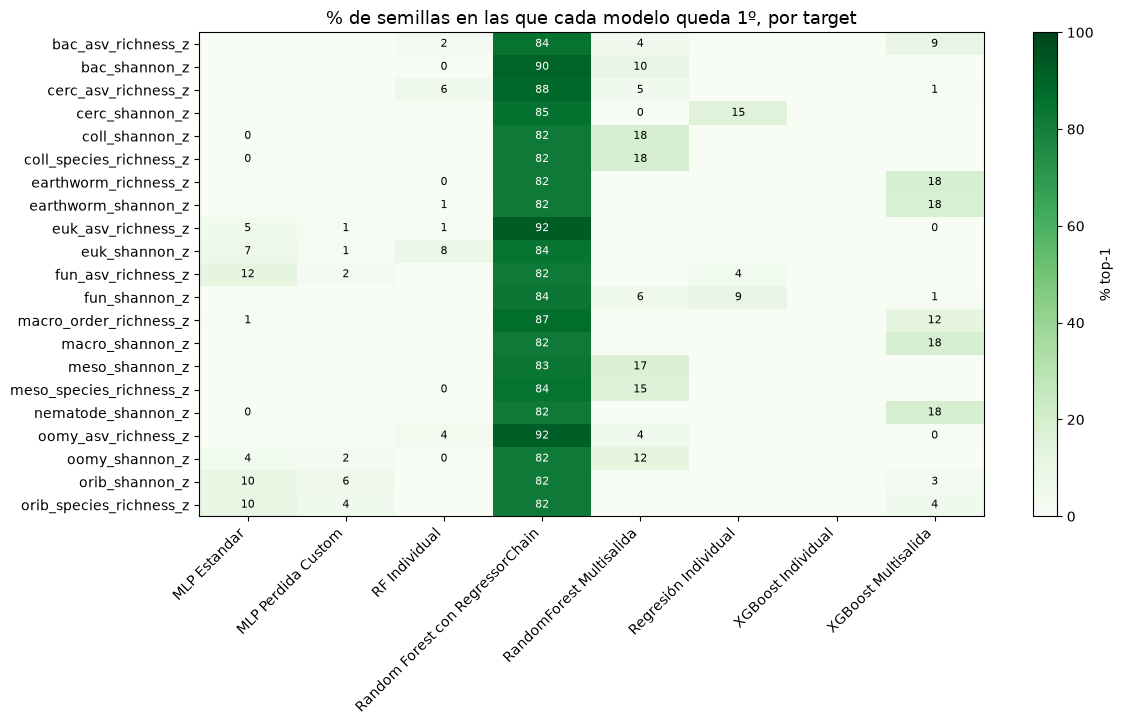

In [10]:
pivot_top1 = resumen_por_target.pivot(index='target', columns='Modelo', values='pct_top1').fillna(0)

fig, ax = plt.subplots(figsize=(12, max(6, 0.35 * len(pivot_top1))))
im = ax.imshow(pivot_top1.values, cmap='Greens', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(len(pivot_top1.columns)))
ax.set_xticklabels(pivot_top1.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot_top1.index)))
ax.set_yticklabels(pivot_top1.index)

for i in range(pivot_top1.shape[0]):
    for j in range(pivot_top1.shape[1]):
        val = pivot_top1.values[i, j]
        if val > 0:
            ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                    color='white' if val > 50 else 'black', fontsize=8)

ax.set_title('% de semillas en las que cada modelo queda 1º, por target', fontsize=13)
plt.colorbar(im, ax=ax, label='% top-1')
plt.tight_layout()
fig.savefig('output/regresion/graphs/barrido_rs_top1_por_target.png', dpi=250, bbox_inches='tight')
plt.show()


## B.5 Exportación de resultados por target

In [11]:
df_barrido_por_target.to_csv('output/regresion/barrido_rs_todos_los_modelos_por_target.csv', index=False)
df_rankings_target.to_csv('output/regresion/barrido_rs_rankings_por_semilla_target.csv', index=False)
resumen_por_target.to_csv('output/regresion/barrido_rs_resumen_por_target.csv', index=False)
ganador_por_target.to_csv('output/regresion/barrido_rs_ganador_por_target.csv')

print('Guardado:')
print('  barrido_rs_todos_los_modelos_por_target.csv   (modelo x semilla x target)')
print('  barrido_rs_rankings_por_semilla_target.csv    (posicion de cada modelo, por semilla y target)')
print('  barrido_rs_resumen_por_target.csv             (media/std/top1/top3 por modelo y target)')
print('  barrido_rs_ganador_por_target.csv             (modelo mas prominente por target)')


Guardado:
  barrido_rs_todos_los_modelos_por_target.csv   (modelo x semilla x target)
  barrido_rs_rankings_por_semilla_target.csv    (posicion de cada modelo, por semilla y target)
  barrido_rs_resumen_por_target.csv             (media/std/top1/top3 por modelo y target)
  barrido_rs_ganador_por_target.csv             (modelo mas prominente por target)


## Conclusiones (Prueba 3)

El barrido de 101 semillas descarta la idea de un único modelo "ganador universal": aunque XGBoost Multisalida es el más prominente en el ranking global (99% de las semillas en el top-1, R² medio 0.5605) y en los dos targets prioritarios del proyecto, el desglose target a target muestra que **el modelo más robusto depende del target**. La recomendación es adoptar una estrategia de modelo específico por grupo de targets, no un modelo único para los 21.

**Modelo recomendado por target** (según frecuencia de top-1 a lo largo de las 101 semillas):

| Modelo | Targets donde es el más prominente | Nº targets |
|---|---|---|
| **XGBoost Multisalida** | `earthworm_shannon_z` (92%), `earthworm_richness_z` (94%), `macro_shannon_z` (100%), `nematode_shannon_z` (98%), `macro_order_richness_z` (58%), `bac_asv_richness_z` (55%) | 6 |
| **Random Forest Multisalida** | `bac_shannon_z` (59%), `meso_shannon_z` (96%), `meso_species_richness_z` (86%), `oomy_shannon_z` (72%), `coll_shannon_z` (99%)*, `coll_species_richness_z` (100%)* | 6 |
| **RF con RegressorChain** | `euk_asv_richness_z` (67%), `euk_shannon_z` (38%), `oomy_asv_richness_z` (75%) | 3 |
| **MLP Estándar** | `fun_asv_richness_z` (55%), `orib_shannon_z` (71%), `orib_species_richness_z` (65%) | 3 |
| **Ridge (Regresión Individual)** | `cerc_shannon_z` (58%), `fun_shannon_z` (47%) | 2 |
| **RF Individual** | `cerc_asv_richness_z` (44%) | 1 |

*Los targets marcados con asterisco (`coll_shannon_z`, `coll_species_richness_z`) tienen R² medio negativo (-0.19 y -0.30) incluso con el modelo ganador — ningún modelo alcanza un ajuste aceptable ahí. "Ganar" en estos casos significa ser el menos malo, no un modelo fiable; se recomienda no usar sus predicciones para conclusiones ecológicas sin más validación, o tratarlos como targets no modelizables con los datos actuales.

**Para los dos targets prioritarios del TFG** (`earthworm_shannon_z`, `earthworm_richness_z`), la elección de XGBoost Multisalida queda respaldada de forma robusta por las 101 semillas (92-94% de dominancia), consistente con el resultado global.

**Siguiente paso:** antes de fijar esta tabla como definitiva, confirmar que `XGB_OPTIMAL_PARAMS` no tiene `subsample`/`colsample_*` en 1.0 de forma que anule por completo la influencia de `random_state` en XGBoost Individual (ver aviso técnico en el desarrollo de esta prueba) — de ser así, no afecta a esta conclusión (que se basa en XGBoost *Multisalida*, no en el individual), pero conviene dejarlo anotado como limitación conocida del experimento.